## Toy example with VAE latent manifold

In this notebook, precomputed models of a VAE trained on a toy dataset and a corresponding trained latent representation are used. It demonstrates how to:

- Compute **geodesics** and the **exponential map** using the learned representation function.
- Compare geodesics with:
  - Euclidean metric
  - Pullback of the Euclidean metric
  - metric based on KL divergence of decoder distributions
- Compare with a naive approach that interpolates in the **full latent space** without using the representation function.

---

This notebook uses pretrained models saved in [saved_models](saved_mdoels). To reproduce the results without using the pretrained models do the following

**Step 1**
- Execute `VAEvar.py` to train the VAE on the toy example, it saves the latent embedding as a point cloud.  
  
**Step 2**
- Train the latent representation using the latent samples. Change the paths in the json file [saved_models/args_latentrep.json](saved_models/args_latentrep.json) to your saved embedding
  and then execute

  `python scripts/train_latent_representation.py --config examples/VAE_example/saved_models/args_latentrep.json` 

  the resulting model will be saved in the main `run` folder per default but you can also specify a save folder with the `-s` keyword


In [ ]:
import torch

if torch.cuda.is_available():
    torch.set_default_tensor_type(torch.cuda.FloatTensor)
else:
    torch.set_default_tensor_type(torch.FloatTensor)

from pathlib import Path
base_path = Path.cwd()

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt

### load trained VAE 

In [3]:
from VAEvar import VAE
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# load VAE network
network_path_vae = base_path / "saved_models/vae_precomputed_model_state.pth"
autoencoder = VAE(input_dim=3, hidden_dim=32, latent_dim=2)
autoencoder.load_state_dict(torch.load(network_path_vae))

#load input data
data = np.load(base_path / "data/hole_3d_noise.npy")
data = torch.tensor(data, dtype=torch.float32)
embedding = autoencoder.encode(data.to(device))[0].detach().cpu().numpy()

Text(0.5, 1.0, 'Latent samples')

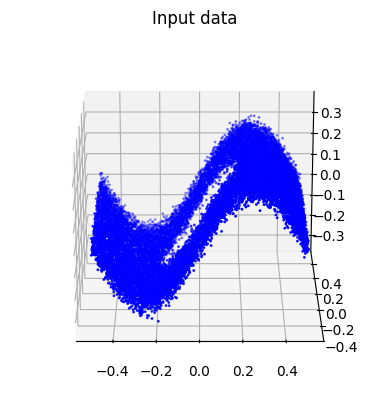

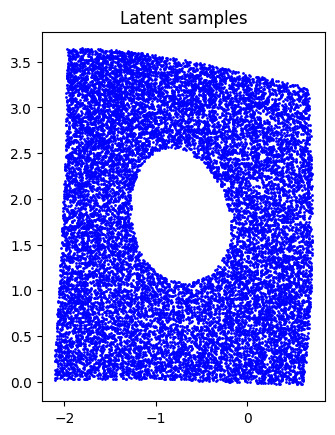

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data.detach().cpu()[:,0], data.detach().cpu()[:,1], data.detach().cpu()[:,2], c='b', marker='o', s=1)
ax.view_init(elev=20., azim=-90)
ax.set_title("Input data")

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(embedding[:,0], embedding[:,1],c='b', marker='o', s=1)
ax.set_aspect('equal', 'box')
ax.set_title("Latent samples")

### load latent representation and visualise the learned function

In [12]:
from latentgeodesics import setup_latent_network, GeodesicSolverTorch

In [13]:
# load trained representation
latentrep_path = base_path / "saved_models/latentrep_state_dict_best.pth"
latentrep_args = base_path  /"saved_models/args_latentrep.json"
network_weights = torch.load(latentrep_path)
args = json.load(open(latentrep_args , "r"))

latentprojector = setup_latent_network(latentrep_args).to(device)
latentprojector.load_state_dict(network_weights)

#representation function
phi = latentprojector.phi(use_torch=True)
dphi = latentprojector.dphi(use_torch=True) #used for exponential map

In [14]:
ldim = args["architecture"]["latent_dim"]

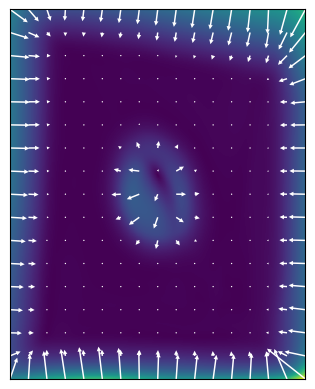

In [15]:
# only for visualization of representation function 
def level_sets(coord):
    phi_level = torch.norm(phi(coord).T, dim = 1)
    return phi_level

#Grid
VOLUME_PLOT_RESOLUTION = 128*2
offset = 0.3
x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()

X = np.linspace(x_min - offset, x_max + offset, VOLUME_PLOT_RESOLUTION, dtype='float32')
Y = np.linspace(y_min - offset, y_max + offset, VOLUME_PLOT_RESOLUTION, dtype='float32')
XX, YY = np.meshgrid(X, Y)

coords_flat = np.column_stack([XX.ravel(), YY.ravel()])  # Shape (n, 3)
all_data_dim = torch.tensor(coords_flat, dtype=torch.float32)
batch_size = 2048
split_data = torch.split(all_data_dim, batch_size)

with torch.no_grad():
        value = torch.cat([level_sets(v.to(latentprojector.device())) for v in split_data]).cpu()

X = np.linspace(x_min - offset, x_max + offset, int(VOLUME_PLOT_RESOLUTION/15), dtype='float32')
Y = np.linspace(y_min - offset, y_max + offset, int(VOLUME_PLOT_RESOLUTION/15), dtype='float32')
XX, YY = np.meshgrid(X, Y)

coords_flat = np.column_stack([XX.ravel(), YY.ravel()])  # Shape (n, 3)
all_data_dim = torch.tensor(coords_flat, dtype=torch.float32)
split_data = torch.split(all_data_dim, batch_size)

with torch.no_grad():
        valueproj = torch.cat([phi(v.to(latentprojector.device())).T for v in split_data]).cpu()
projdir = 0.05* valueproj

fig = plt.figure()
ax = fig.add_subplot(111)
ax.axes.get_xaxis().set_ticks([])
ax.axes.get_yaxis().set_ticks([])#
ax.set_aspect('equal')
contour = ax.imshow(value.detach().numpy().flatten().reshape(VOLUME_PLOT_RESOLUTION, VOLUME_PLOT_RESOLUTION), extent=[ x_min-offset, x_max +offset, y_min-offset, y_max+offset ] ,cmap = 'viridis', origin='lower')
q = ax.quiver(coords_flat[:,0], coords_flat[:,1], projdir[:,0], projdir[:,1], width=0.005, scale=0.3, headwidth=3,headlength=3,headaxislength=3, color = 'white')

# Compute Geodesics

In [16]:
#initialize solver, default is using eucldiean metric
Solver = GeodesicSolverTorch(ldim,phi)

In [ ]:
#specify start and end point
xA = torch.tensor(embedding[4990], dtype = torch.float32)
xB = torch.tensor(embedding[1350], dtype = torch.float32)
#resolution of geodesic
K = 30

geodesic = Solver.AugLagrangeMinimize(K, xA=xA, xB=xB, mu=10, maxmu=10e2, alpha=2, disp=False)

decoded_geodesic = autoencoder.decode(geodesic)[0].detach().cpu().numpy()
geodesic = geodesic.detach().cpu().numpy()

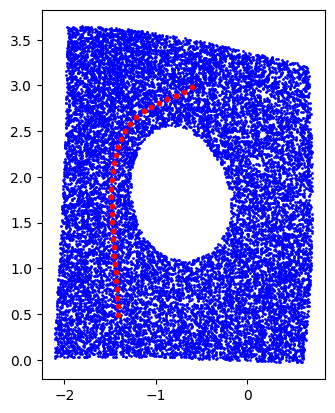

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(embedding[:,0], embedding[:,1], c='b', marker='o', s=1)
ax.set_aspect('equal')
ax.scatter(geodesic[:,0], geodesic[:,1], c='r', marker='o', s=10, alpha=1)

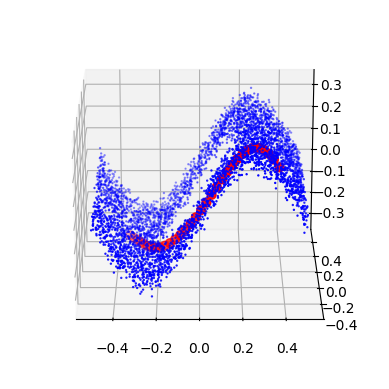

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data.detach().cpu()[::4,0], data.detach().cpu()[::4,1], data.detach().cpu()[::4,2], c='b', marker='o', s=0.5)
ax.scatter(decoded_geodesic[:,0], decoded_geodesic[:,1], decoded_geodesic[:,2], c='r', marker='o', s=40)
ax.view_init(elev=20., azim=-90)

### Using different latent space metrics

Instead of the default Euclidean metric, geodesics can also be computed using the **pullback euclidean metric**. In the VAE setting with variable decoder variance the **KL divergence** between decoder distributions can be used as an approximation of the squared distance. For this the Solver can be provided with custom functions `sqdist` with signature: sqdist(x, y) -> torch.Tensor (scalar)

 Some are implemented in `src/latentgeodesics/geodesics/metrics.py`.

In [20]:
from latentgeodesics import sqdist_KL, sqdist_pbeuclid

In [21]:
# the decoder returns mean and logvar, we only need the mean for the pullback euclidean metric
decoder = lambda z: autoencoder.decode(z)[0]
PBeucl  = lambda z1, z2 : sqdist_pbeuclid(z1, z2, decoder, args=None)

# for KL metric we need the full decoder output
KLmetric = lambda z1, z2 : sqdist_KL(z1, z2, autoencoder.decode, args=None)

PBSolver = GeodesicSolverTorch(ldim, phi, sqdist = PBeucl)
KLSolver = GeodesicSolverTorch(ldim, phi, sqdist = KLmetric)

In [ ]:
xA_torch = torch.tensor(embedding[4990], dtype = torch.float32)
xB_torch = torch.tensor(embedding[1350], dtype = torch.float32)

K = 30

pbgeodesic = PBSolver.AugLagrangeMinimize(K,xA=xA_torch, xB=xB_torch, mu=10, maxmu=10e2, alpha=2, disp=False)
pbgeodesic = pbgeodesic.detach().cpu().numpy()

In [23]:
pbdecoded = autoencoder.decode(torch.tensor(pbgeodesic, dtype=torch.float32).to(device))[0].detach().cpu().numpy()

In [ ]:
xA_torch = torch.tensor(embedding[4990], dtype = torch.float32)
xB_torch = torch.tensor(embedding[1350], dtype = torch.float32)

K = 30

KLgeodesic = KLSolver.AugLagrangeMinimize(K,xA=xA_torch, xB=xB_torch, mu=10, maxmu=10e2, alpha=2, disp=False)
KLgeodesic = KLgeodesic.detach().cpu().numpy()

In [25]:
kldecoded = autoencoder.decode(torch.tensor(KLgeodesic, dtype=torch.float32).to(device))[0].detach().cpu().numpy()

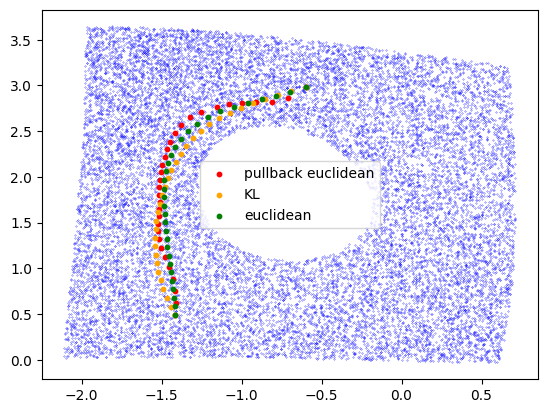

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(embedding[:,0], embedding[:,1], c='b', marker='o', s=0.05)
ax.scatter(pbgeodesic[:,0], pbgeodesic[:,1], c='r', marker='o', s=10, label = 'pullback euclidean')
ax.scatter(KLgeodesic[:,0], KLgeodesic[:,1], c='orange', marker='o', s=10, label='KL')
ax.scatter(geodesic[:,0], geodesic[:,1], c='g', marker='o', s=10, label= 'euclidean')
ax.legend()

# Exponential 
We show how to compute the exponential map with euclidean metric and pullback of the euclidean metric. 
For manifolds with boundaries as in this example, the exponential is not well defined once it hits the boundary. However, it bounces back as expected.

In [27]:
from latentgeodesics import KExponentialTorch

In [ ]:
K = 15
#define some initial direction
v = K*(geodesic[0] +0.05 - geodesic[0])
xA = torch.tensor(geodesic[0], dtype = torch.float32)
v = torch.tensor(v, dtype = torch.float32)
exp = KExponentialTorch(phi, dphi, xA, v, K, constrfact=0.01)
exp = exp.detach().cpu().numpy()

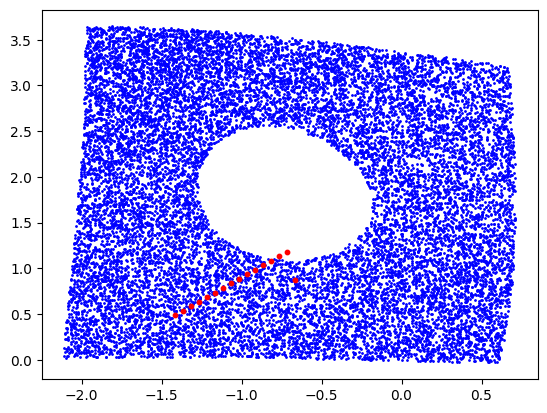

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(embedding[:,0], embedding[:,1], c='b', marker='o', s=1)
ax.scatter(exp[:,0], exp[:,1], c='r', marker='o', s=10)

In [30]:
from latentgeodesics import mix_hess_sqdist_pbeuclid, grad_sqdist
# for the exponential we have to pass gradient and mixed second derivatives, as the function uses a manual gradient implementation to avoid second order autograds.
# the mixed second derivatives of the pullback euclidean distance only needs first order autograd
DPBeucl = lambda z1, z2, wrt_first: grad_sqdist(z1, z2, decoder, sqdist_pbeuclid, wrt_first)
DDPBeucl = lambda z1, z2, wrt_first: mix_hess_sqdist_pbeuclid(z1, z2, decoder, wrt_first)

In [ ]:
K = 15
v = K*(geodesic[0] +0.05 - geodesic[0])
xA = torch.tensor(geodesic[0], dtype = torch.float32)
v = torch.tensor(v, dtype = torch.float32)
exp = KExponentialTorch(phi, dphi, xA, v, K, sqdist=PBeucl, gradsqdist=DPBeucl, mixhesssqdist=DDPBeucl, constrfact=0.01, firstStep='linear')
exp = exp.detach().cpu().numpy()

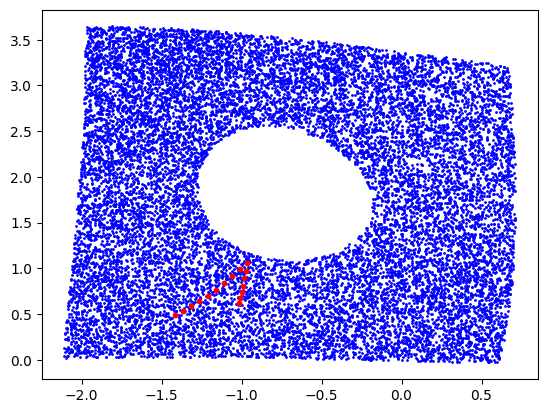

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(embedding[:,0], embedding[:,1], c='b', marker='o', s=1)
ax.scatter(exp[:,0], exp[:,1], c='r', marker='o', s=10)